=== Category Classification ===
Accuracy: 0.60
              precision    recall  f1-score   support

     account       0.00      0.00      0.00         1
     billing       1.00      1.00      1.00         1
     general       0.00      0.00      0.00         1
   technical       0.50      1.00      0.67         2

    accuracy                           0.60         5
   macro avg       0.38      0.50      0.42         5
weighted avg       0.40      0.60      0.47         5


=== Priority Classification ===
Accuracy: 0.60
              precision    recall  f1-score   support

        high       0.50      1.00      0.67         2
         low       0.00      0.00      0.00         1
      medium       1.00      0.50      0.67         2

    accuracy                           0.60         5
   macro avg       0.50      0.50      0.44         5
weighted avg       0.60      0.60      0.53         5


Models and vectorizer saved as .pkl files!


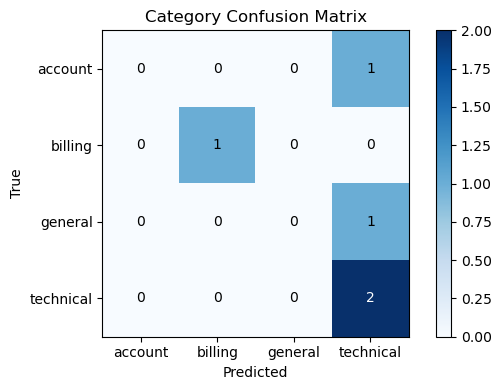

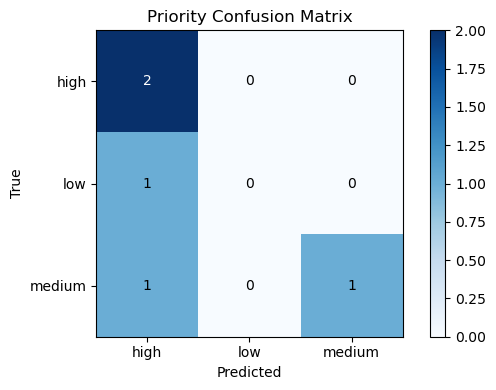


Test Ticket: Urgent help needed: Can't process payment!
→ Category: technical | Priority: medium


In [3]:
# ticket_classifier.ipynb - Future Interns ML Task 2: Support Ticket Classification
# Run this first to train models and save .pkl files for Streamlit

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pickle

# Simple stopword list (no NLTK needed)
STOP_WORDS = {'a', 'an', 'the', 'is', 'in', 'at', 'of', 'on', 'and', 'or', 'to', 'for', 'with', 'by', 'from'}

# Synthetic dataset (replace with real Kaggle CSV later for better accuracy)
data = {
    'ticket_text': [
        "My account is locked and I need to access it immediately!",
        "Billing error: charged twice for the same item.",
        "App crashes every time I open it. Please fix.",
        "How do I reset my password?",
        "Urgent: Data loss in my files!",
        "Question about subscription plans.",
        "Server down, can't access website.",
        "Refund request for incorrect purchase.",
        "Need help with installation.",
        "Critical bug: payment not processing.",
        "General inquiry about your services.",
        "Account hacked, change password now!",
        "Overcharged on my bill this month.",
        "Software update failed.",
        "Where can I find the user manual?",
        "Emergency: System outage affecting business.",
        "Feedback on the new feature.",
        "Login issues persist.",
        "Dispute a transaction.",
        "Tutorial on using the API.",
        "High priority: Security breach suspected.",
        "Monthly statement incorrect.",
        "App not compatible with my device.",
        "Cancel my subscription please.",
        "Immediate assistance: Can't log in to email."
    ],
    'category': ['account', 'billing', 'technical', 'account', 'technical', 'general', 'technical', 'billing', 'technical', 'technical',
                 'general', 'account', 'billing', 'technical', 'general', 'technical', 'general', 'account', 'billing', 'general',
                 'technical', 'billing', 'technical', 'account', 'account'],
    'priority': ['high', 'medium', 'high', 'low', 'high', 'low', 'high', 'medium', 'medium', 'high',
                 'low', 'high', 'medium', 'medium', 'low', 'high', 'low', 'medium', 'medium', 'low',
                 'high', 'medium', 'medium', 'low', 'high']
}

df = pd.DataFrame(data)

# Text cleaning function
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    words = text.split()
    text = ' '.join(word for word in words if word not in STOP_WORDS)
    return text

df['cleaned_text'] = df['ticket_text'].apply(clean_text)

# Features and targets
X = df['cleaned_text']
y_category = df['category']
y_priority = df['priority']

# Stratified split to preserve class distribution
X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42, stratify=y_category
)
X_train_p, X_test_p, y_pri_train, y_pri_test = train_test_split(
    X, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

# TF-IDF Vectorizer with bigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Category Model: Logistic Regression with balanced weights
cat_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
cat_model.fit(X_train_vec, y_cat_train)
cat_pred = cat_model.predict(X_test_vec)

# Priority Model: Naive Bayes (great for text)
pri_model = MultinomialNB()
pri_model.fit(X_train_vec, y_pri_train)
pri_pred = pri_model.predict(X_test_vec)

# Evaluation
print("=== Category Classification ===")
print(f"Accuracy: {accuracy_score(y_cat_test, cat_pred):.2f}")
print(classification_report(y_cat_test, cat_pred, zero_division=0))

print("\n=== Priority Classification ===")
print(f"Accuracy: {accuracy_score(y_pri_test, pri_pred):.2f}")
print(classification_report(y_pri_test, pri_pred, zero_division=0))

# Save models and vectorizer (critical for Streamlit!)
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))
pickle.dump(cat_model, open('cat_model.pkl', 'wb'))
pickle.dump(pri_model, open('pri_model.pkl', 'wb'))
print("\nModels and vectorizer saved as .pkl files!")

# Optional: Plot confusion matrices
def plot_cm(cm, title, labels):
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(len(labels)), yticks=np.arange(len(labels)),
           xticklabels=labels, yticklabels=labels,
           title=title, ylabel='True', xlabel='Predicted')
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

cat_labels = sorted(df['category'].unique())
pri_labels = sorted(df['priority'].unique())

plot_cm(confusion_matrix(y_cat_test, cat_pred), 'Category Confusion Matrix', cat_labels)
plot_cm(confusion_matrix(y_pri_test, pri_pred), 'Priority Confusion Matrix', pri_labels)

# Prediction function (for testing)
def predict_ticket(text):
    clean = clean_text(text)
    vec = vectorizer.transform([clean])
    cat = cat_model.predict(vec)[0]
    pri = pri_model.predict(vec)[0]
    return cat, pri

# Test example
test_ticket = "Urgent help needed: Can't process payment!"
cat, pri = predict_ticket(test_ticket)
print(f"\nTest Ticket: {test_ticket}")
print(f"→ Category: {cat} | Priority: {pri}")